# 动力学参数辨识
> 进行完整重构
> 重构代码版本，from runModelPulseForce_realconstrast_kc.py


In [1]:
# import
import numpy as np
import time, random, math, scipy, datetime, cv2
import matplotlib.pyplot as plt
import mediapy as media
import pandas as pd
from tqdm import tqdm
import matplotlib.gridspec as gridspec
from matplotlib.widgets import Slider
import ipywidgets as widgets
from IPython.display import display
from scipy.optimize import differential_evolution
from pathlib import Path
import sys, rootpath
root_dir = rootpath.detect()   # Get the root directory of the project (.git)
sys.path.insert(0, root_dir)  # insert at the beginning for higher priority (compatible with both version of python)
from utils.experiment import MujocoExperiment

In [2]:
# Tools
def smooth_data(data, window_size=5, axis=-1):
    """
    对速度数据进行平滑处理
    Args:
        data: 速度数据，shape为(n_experiments, n_joints, n_timesteps)
        window_size: 滑动窗口大小
    Returns:
        smoothed_data: 平滑后的速度数据
    """
    # 使用边缘处理来避免边缘效应
    pad_width = window_size // 2
    # create the padded axis
    _dim = data.ndim
    _paddle_before_after = [(0,0) for _ in range(_dim)]
    _paddle_before_after[-1] = (pad_width, window_size-pad_width-1)     # the size = data_size + pad_size - window_size + 1
    padded_data = np.pad(data, _paddle_before_after, mode='edge')
    
    return np.apply_along_axis(
        lambda x: np.convolve(x, np.ones(window_size)/window_size, mode='valid'),   # 严格使用卷积
        axis=axis,
        arr=padded_data
    )

In [3]:
# Process the real data
# Original data: angles are in degrees, containing pressure1_start, pressure2_start, pressure1_end, pressure2_end, relative_time, thigh_theta21, calf_theta32
start_step_time = 5
pressure_group_num = 6
data_real_path = root_dir + "/src/physical_verify/dynamic/data/ToCenter_2025-02-20_21-06-20_A2B_data.csv"
data_real = pd.read_csv(data_real_path)
data_real["experiment_group"] = data_real.groupby(["pressure1_start", "pressure2_start", "pressure1_end", 
                                     "pressure2_end"]).ngroup()         # 0-35 Groups

expdata_real_lineInterp = []
expdata_real_splineInterp = []
expdata_real_origin = []     # original data
for group_id in data_real["experiment_group"].unique():
    # group_data_real is the data after the step starts
    group_data_real = data_real[data_real["experiment_group"]==group_id]
    group_data_real = group_data_real[group_data_real["relative_time"]>=start_step_time]

    # get the pressure setup of this group
    pressure1_start = group_data_real["pressure1_start"].iloc[0]    # visit data of this group
    pressure2_start = group_data_real["pressure2_start"].iloc[0]
    pressure1_end = group_data_real["pressure1_end"].iloc[0]
    pressure2_end = group_data_real["pressure2_end"].iloc[0]

    # get the data of this group
    time_real = np.array(group_data_real["relative_time"]-start_step_time)
    theta1_real = np.array(group_data_real["thigh_theta21"])
    theta2_real = np.array(group_data_real["calf_theta32"])

    # Interpolation, using linear interpolation and spline interpolation (k=3)
    t_intervel = np.linspace(0, 4, 401)
    delta_t = time_real[1] - time_real[0]

    theta1_real_lineInterp = np.interp(t_intervel, time_real, theta1_real)
    theta2_real_lineInterp = np.interp(t_intervel, time_real, theta2_real)
    theta1_spline = scipy.interpolate.make_interp_spline(time_real, theta1_real, k=3)
    theta2_spline = scipy.interpolate.make_interp_spline(time_real, theta2_real, k=3)
    theta1_real_splineInterp = theta1_spline(t_intervel)
    theta2_real_splineInterp = theta2_spline(t_intervel) 

    # stack all data and record in list
    expdata_real_lineInterp_one = np.stack((t_intervel, theta1_real_lineInterp, theta2_real_lineInterp), axis=0)
    expdata_real_splineInterp_one = np.stack((t_intervel, theta1_real_splineInterp, theta2_real_splineInterp), axis=0)
    expdata_real_origin_one = np.stack((time_real, theta1_real, theta2_real), axis=0)
    expdata_real_lineInterp.append(expdata_real_lineInterp_one)
    expdata_real_splineInterp.append(expdata_real_splineInterp_one)
    expdata_real_origin.append(expdata_real_origin_one)

# convert to numpy array
expdata_real_lineInterp = np.array(expdata_real_lineInterp)
expdata_real_splineInterp = np.array(expdata_real_splineInterp)
# expdata_real_origin = np.array(expdata_real_origin)       # for the length of each group is different, so we can't use np.array

print(f"expdata_real_lineInterp.shape: {expdata_real_lineInterp.shape}")
print(f"expdata_real_splineInterp.shape: {expdata_real_splineInterp.shape}")
print(f"expdata_real_origin.len: {len(expdata_real_origin)}")

# above data is all response of [init pressures], however, we need to select the effective data for the experiment.
data = pd.read_csv(root_dir + "/src/physical_verify/static/data/real_static_state/real(effective)_StaticPoint_6group_2025-02-21_08-55-07_2025-08-01_19-34-21.csv")
P1_array = data['P1 (kPa)'].values
P2_array = data['P2 (kPa)'].values
theta1_array = data['theta1 (deg)'].values
theta2_array = data['theta2 (deg)'].values

# theta1_array = np.array(theta1_array, dtype=np.float32)*np.pi/180  # 输入 theta1
# theta2_array = np.array(theta2_array, dtype=np.float32)*np.pi/180  # 输入 theta2
P1_array = np.array(P1_array, dtype=np.float32)*1000  # 实验输出 P
P2_array = np.array(P2_array, dtype=np.float32)*1000  # 实验输出 P

effective_idx = np.array((P1_array/10000) * pressure_group_num + (P2_array/10000), dtype=np.int16)
print("effective_idx: ", effective_idx)

# effective_idx = [19]  # TODO 30,10

expdata_real_lineInterp_effective = expdata_real_lineInterp[effective_idx]
expdata_real_splineInterp_effective = expdata_real_splineInterp[effective_idx]
expdata_real_origin_effective = [expdata_real_origin[i] for i in effective_idx]
# The shape of data is (13, 3, 401), namely (n_experiments, t-theta1-theta2, n_timesteps)
print(f"expdata_real_lineInterp_effective Shape = {expdata_real_lineInterp_effective.shape}")
print(f"expdata_real_splineInterp_effective Shape = {expdata_real_splineInterp_effective.shape}")
print(f"expdata_real_origin_effective Len = {len(expdata_real_origin_effective)}")


expdata_real_lineInterp.shape: (36, 3, 401)
expdata_real_splineInterp.shape: (36, 3, 401)
expdata_real_origin.len: 36
effective_idx:  [ 0  1  2  3  6  7  8 12 13 18 19 24 30]
expdata_real_lineInterp_effective Shape = (13, 3, 401)
expdata_real_splineInterp_effective Shape = (13, 3, 401)
expdata_real_origin_effective Len = 13


In [4]:
# show the real data
interest_group_slider = widgets.IntSlider(value=0, min=0, max=len(expdata_real_lineInterp_effective)-1, step=1, description='Interest Group:')
window_size_slider = widgets.IntSlider(value=5, min=1, max=20, step=1, description='Window Size:')

def update_plot(interest_group, window_size=5):
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))

    # # 在图中展示当前选择组的气压值
    # plt.text(0.02, 0.98, f'P1 = {P1_array[interest_group]/1000:.2f} kPa', transform=plt.gca().transAxes)
    # plt.text(0.02, 0.93, f'P2 = {P2_array[interest_group]/1000:.2f} kPa', transform=plt.gca().transAxes)

    # plt.subplot(2, 1, 1)  # 创建一个2行1列的子图，选择第二个子图
    expdata_effective = expdata_real_lineInterp_effective[interest_group]
    ax[0].plot(expdata_effective[0], expdata_effective[1], color='blue', linestyle=':', alpha=0.3, label=r'Line Interpolated $\theta_1$')
    ax[0].plot(expdata_effective[0], expdata_effective[2], color='orange', linestyle=':', alpha=0.3, label=r'Line Interpolated $\theta_2$')

    expdata_effective = expdata_real_splineInterp_effective[interest_group]
    ax[0].plot(expdata_effective[0], expdata_effective[1], color='green', alpha=0.3, linestyle="--", label=r'Spline Interpolated $\theta_1$')
    ax[0].plot(expdata_effective[0], expdata_effective[2], color='red', alpha=0.3, linestyle="--", label=r'Spline Interpolated $\theta_2$')

    expdata_effective = expdata_real_origin_effective[interest_group]
    ax[0].plot(expdata_effective[0], expdata_effective[1], color='blue', alpha=0.3, linestyle='-', label=r'Real $\theta_1$')
    ax[0].plot(expdata_effective[0], expdata_effective[2], color='orange', alpha=0.3, linestyle='-', label=r'Real $\theta_2$')

    # plot the smooth data of the expdata_real_lineInterp_effective
    expdata_effective = expdata_real_lineInterp_effective[interest_group]
    theta1_smooth = smooth_data(expdata_effective[1][np.newaxis, :], window_size=window_size)[0]
    theta2_smooth = smooth_data(expdata_effective[2][np.newaxis, :], window_size=window_size)[0]
    # print(theta1_smooth.shape)
    ax[0].plot(expdata_effective[0], theta1_smooth, color='blue', linestyle='-', label=r'Smooth Line Interpolated $\theta_1$')
    ax[0].plot(expdata_effective[0], theta2_smooth, color='orange', linestyle='-', label=r'Smooth Line Interpolated $\theta_2$')

    ax[0].set_title('Real Data, Line Interpolated and Spline Interpolated Data')
    # ax[0].set_xlabel('Time (s)')
    ax[0].set_ylabel('Angle (deg)')
    ax[0].set_xlim(0, 2)
    ax[0].set_ylim(0, 120)
    ax[0].legend(loc='upper right', fontsize='medium', frameon=True)
    ax[0].grid()
    plt.tight_layout()

    # 利用中心差分计算速度
    velocity1 = np.gradient(theta1_smooth, axis=-1)/delta_t
    velocity2 = np.gradient(theta2_smooth, axis=-1)/delta_t
    # plt.subplot(2, 1, 2)  # 创建一个2行1列的子图，选择第二个子图
    ax[1].plot(expdata_effective[0], velocity1, color='blue', linestyle='-', label=r'Velocity $\theta_1$')
    ax[1].plot(expdata_effective[0], velocity2, color='orange', linestyle='-', label=r'Velocity $\theta_2$')
    ax[1].set_title('Velocity of Angles')
    ax[1].set_xlabel('Time (s)')
    ax[1].set_ylabel('Velocity (deg/s)')
    ax[1].set_xlim(0, 2)
    ax[1].set_ylim(-100, 100)
    ax[1].legend(loc='upper right', fontsize='medium', frameon=True)
    ax[1].grid()

    # tight
    plt.tight_layout()
    plt.show()

# 绑定滑块的值变化到更新函数
widgets.interactive(update_plot, interest_group=interest_group_slider, window_size=window_size_slider)


interactive(children=(IntSlider(value=0, description='Interest Group:', max=12), IntSlider(value=5, descriptio…

(13, 3, 401)


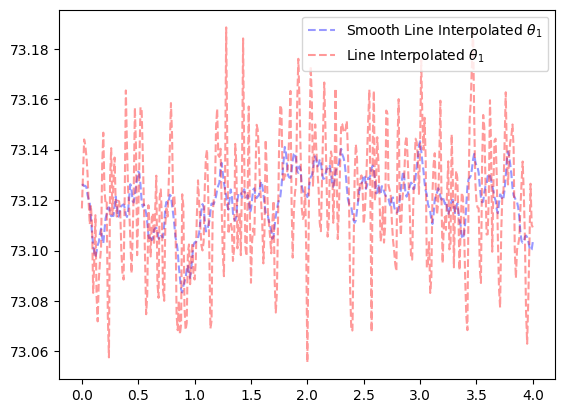

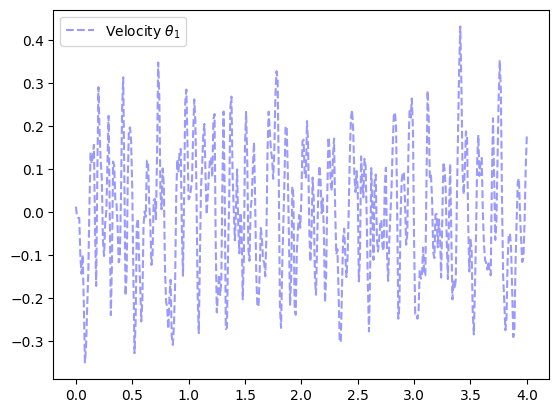

In [5]:
# 实验数据再处理：滑动平均
# 这是真正用的数据
expdata_real_lineInterp_effective_smooth = smooth_data(expdata_real_lineInterp_effective, window_size=11, axis=-1)
velocity_real_lineInterp_effective_presmooth = np.gradient(expdata_real_lineInterp_effective_smooth, axis=-1)/delta_t

print(expdata_real_lineInterp_effective_smooth.shape)
plt.plot(expdata_real_lineInterp_effective[0, 0], expdata_real_lineInterp_effective_smooth[0, 1], color='blue', alpha=0.4, linestyle='--', label=r'Smooth Line Interpolated $\theta_1$')
plt.plot(expdata_real_lineInterp_effective[0, 0], expdata_real_lineInterp_effective[0, 1], color='red', alpha=0.4, linestyle='--', label=r'Line Interpolated $\theta_1$')
plt.legend()

plt.figure()
plt.plot(expdata_real_lineInterp_effective[0, 0], velocity_real_lineInterp_effective_presmooth[0, 1], color='blue', alpha=0.4, linestyle='--', label=r'Velocity $\theta_1$')
plt.legend()


In [235]:
# Sim Data Collection
# NOTE: 注意这里是双层 try and else ~

path = (root_dir + "/models/v2_4/urdf/dog2_4singleLeg_realconstrast.xml")
experiment_instance = MujocoExperiment(path, xml_mode=True)

# a function wrapper to run the experiment and return the results
def run_single_experiment(params, ifrender=False, valveDynamics=False):
    """
    Run a single experiment with the given parameters.
    Args:
        params (dict): Dictionary of parameters to set for the experiment.
    Returns:
        time_sim (ndarray): Simulated time data.
        theta1_sim (ndarray): Simulated angle data for joint 1.
        theta2_sim (ndarray): Simulated angle data for joint 2.
        frames (list): List of frames generated during the simulation.
    """
    try:
        # Run the simulation
        time_step = 10
        duration_exp = 20
        time_sim, theta1_sim, theta2_sim, frames, _, _ = experiment_instance.run(params, time_step=time_step, duration=duration_exp, ifrender=ifrender)
        return time_sim, theta1_sim, theta2_sim, frames
    # ctrl C to quit
    except KeyboardInterrupt:
        pass

t_bias = 10         # TODO

# define the error function
def error(para, mode="train", t_bias=t_bias, return_type="error"):
    '''return the error/frames'''
    expdata_sim_all = []
    for p1, p2 in zip(P1_array[:], P2_array[:]):
      para["P1"] = p1
      para["P2"] = p2
      time_sim, theta1_sim, theta2_sim, frames = run_single_experiment(para, ifrender=False) 
         
      time_sim = time_sim - t_bias
      t_intervel = np.linspace(0, 4, 401)
      theta1_sim_intervel = np.interp(t_intervel, time_sim, theta1_sim) * 180 / np.pi
      theta2_sim_intervel = np.interp(t_intervel, time_sim, theta2_sim) * 180 / np.pi

      expdata_sim = np.stack((t_intervel, theta1_sim_intervel, theta2_sim_intervel), axis=0)  # 3*401
      expdata_sim_all.append(expdata_sim)
    expdata_sim_all = np.array(expdata_sim_all)   # 13*3*401

    # Error of theta1 and theta2
    q_errorMat = expdata_sim_all - expdata_real_lineInterp_effective_smooth
    q_SE_mat = q_errorMat**2
    q_MSE_mat = np.mean(q_SE_mat, axis=2)   # along the time axis
    q_MSE_mat_overview = np.mean(q_MSE_mat, axis=0) # along the group axis
    q_MSE_sum = np.mean(q_MSE_mat_overview[1:]) # along the joint axis(MSE of theta1 plus MSE of theta2)
    q_RMSE = np.sqrt(q_MSE_sum)

    # Error of angular velocity(vs velocity_real_lineInterp_effective_presmooth)
    qd_sim = np.gradient(expdata_sim_all, axis=-1)/delta_t
    qd_errorMat = qd_sim - velocity_real_lineInterp_effective_presmooth
    qd_SE_mat = qd_errorMat**2
    qd_MSE_mat = np.mean(qd_SE_mat, axis=2)
    qd_MSE_mat_overview = np.mean(qd_MSE_mat, axis=0)
    qd_MSE_sum = np.mean(qd_MSE_mat_overview[1:])   # along the joint axis(MSE of theta1 plus MSE of theta2)
    # print(f"q_MSE_sum: {q_MSE_sum:.4f}, qd_MSE_sum: {qd_MSE_sum:.4f}")
    velocity_sim_sign = np.where(qd_sim > 0, 1, -1)
    velocity_real_sign = np.where(velocity_real_lineInterp_effective_presmooth > 0, 1, -1)
    errorMat_velocity = np.where(velocity_sim_sign == velocity_real_sign, 0, 1)
    errorMat_velocity_sum = np.mean(errorMat_velocity, axis=0)  # along the group axis
    errorMat_velocity_sum = np.mean(errorMat_velocity_sum[1:])  # along the joint axis
    errorMat_velocity_sum_mean = np.mean(errorMat_velocity_sum)

    # print(f"[RMSE]: {np.sqrt(q_MSE_sum):.8f}")
    if return_type == "frames":
        return q_RMSE, expdata_sim_all
    elif return_type == "error":
        return q_RMSE + 0*q_MSE_sum + 0*100*errorMat_velocity_sum_mean


k1_opt = 265.8241475038647
k2_opt = 110.35587085946752
l10_opt = 0.18030933265375373
l20_opt = 0.2565263437073504
c1_opt = 12.481528852527212
c2_opt = 24.786338846294175
s1_opt = 0.000402878523871013
s2_opt = 0.0004359278762327848
c1_thigh_opt = 0.5235405629870382
c2_calf_opt = 0.06173716079499769

# mass set
RB_MAA_uGeom = 0.03108
RB_MAA_mGeom = 0.12432
RB_MAA_lGeom = 0.03108

RB_BAA_uGeom = 0.04544333333
RB_BAA_mGeom = 0.1817733333
RB_BAA_lGeom = 0.04544333333

para = {
  'stiffness_MAA': k1_opt,
  'stiffness_BAA': k2_opt,
  'l10': l10_opt,
  'l20': l20_opt,
  'damping_MAA': c1_opt,
  'damping_BAA': c2_opt,
  's1': s1_opt,
  's2': s2_opt,
  'c1_thigh': c1_thigh_opt,
  'c2_calf': c2_calf_opt,
  'P1': 0,        # to set from the experimental data
  'P2': 0,
  'P1_prime': 0.0,
  'P2_prime': 0.0,
  'RB_MAA_uGeom': RB_MAA_uGeom,
  'RB_MAA_mGeom': RB_MAA_mGeom,
  'RB_MAA_lGeom': RB_MAA_lGeom,
  'RB_BAA_uGeom': RB_BAA_uGeom,
  'RB_BAA_mGeom': RB_BAA_mGeom,
  'RB_BAA_lGeom': RB_BAA_lGeom,
}

# k1, k2, l10, l20, c1, c2, s1, s2, c1_thigh, c2_calf = params
print(error(para))

1.8633574817808098


1.8633574817808098


In [126]:

def sensitivity_analysis(base_para, keys_to_analyze, delta_ratio=0.05):
    base_error = error(base_para)
    results = []

    for key in keys_to_analyze:
        if key not in base_para:
            continue
        
        original_value = base_para[key]
        if original_value == 0:
            continue  # 避免除0错误

        # 生成扰动值
        delta = original_value * delta_ratio

        # 正向扰动
        para_plus = base_para.copy()
        para_plus[key] += delta
        error_plus = error(para_plus)
        sens_plus = (error_plus - base_error) / delta
        rel_sens_plus = (error_plus - base_error) / base_error / delta_ratio

        # # 负向扰动
        # para_minus = base_para.copy()
        # para_minus[key] -= delta
        # error_minus = error(para_minus)
        # sens_minus = (error_minus - base_error) / delta
        # rel_sens_minus = (error_minus - base_error) / base_error / delta_ratio

        results.append({
            'parameter': key,
            'base_value': original_value,
            'delta_ratio': delta_ratio,
            'error_base': base_error,
            'error_plus': error_plus,
            # 'error_minus': error_minus,
            'sensitivity_plus': sens_plus,
            # 'sensitivity_minus': sens_minus,
            'relative_sensitivity_plus': rel_sens_plus,
            # 'relative_sensitivity_minus': rel_sens_minus
        })

    return results

keys = ['RB_MAA_uGeom', 'RB_MAA_mGeom', 'RB_MAA_lGeom', 'RB_BAA_uGeom', 'RB_BAA_mGeom', 'RB_BAA_lGeom',
        'stiffness_MAA', 'stiffness_BAA', 'l10', 'l20', 'damping_MAA', 'damping_BAA', 's1', 's2']
delta_ratios = [-0.1, -0.05, -0.01, 0.01, 0.05, 0.1]
result_log = []
for idx in tqdm(range(len(delta_ratios))):
    df_sens = sensitivity_analysis(para, keys, delta_ratio=delta_ratios[idx])
    result_log += df_sens

print(result_log)

100%|██████████| 6/6 [01:52<00:00, 18.82s/it]

[{'parameter': 'RB_MAA_uGeom', 'base_value': 0.03108, 'delta_ratio': -0.1, 'error_base': np.float64(1.8633574817808098), 'error_plus': np.float64(1.8633574853231512), 'sensitivity_plus': np.float64(-1.1397494559751088e-06), 'relative_sensitivity_plus': np.float64(-1.901052988385902e-08)}, {'parameter': 'RB_MAA_mGeom', 'base_value': 0.12432, 'delta_ratio': -0.1, 'error_base': np.float64(1.8633574817808098), 'error_plus': np.float64(1.846278796704732), 'sensitivity_plus': np.float64(1.373768104575112), 'relative_sensitivity_plus': np.float64(0.0916554404780971)}, {'parameter': 'RB_MAA_lGeom', 'base_value': 0.03108, 'delta_ratio': -0.1, 'error_base': np.float64(1.8633574817808098), 'error_plus': np.float64(1.8538393097705652), 'sensitivity_plus': np.float64(3.0624749067711163), 'relative_sensitivity_plus': np.float64(0.05108076202934563)}, {'parameter': 'RB_BAA_uGeom', 'base_value': 0.04544333333, 'delta_ratio': -0.1, 'error_base': np.float64(1.8633574817808098), 'error_plus': np.float64(

In [26]:
_dic = {
    "alice": 'on',
    "bob": np.float32(32)
}

_dic2 = {
    "alice": 'up',
    "bob": 286
}

list_test = []
list_test.append(_dic)
list_test.append(_dic2)
list_log = pd.DataFrame(list_test)
list_log

,alice,bob
0,on,32.0
1,up,286.0


In [128]:

result_log_df = pd.DataFrame(result_log)
result_log_df


,parameter,base_value,delta_ratio,error_base,error_plus,sensitivity_plus,relative_sensitivity_plus
0,RB_MAA_uGeom,0.031080,-0.1,1.863357,1.863357,-1.139749e-06,-1.901053e-08
1,RB_MAA_mGeom,0.124320,-0.1,1.863357,1.846279,1.373768e+00,9.165544e-02
2,RB_MAA_lGeom,0.031080,-0.1,1.863357,1.853839,3.062475e+00,5.108076e-02
3,RB_BAA_uGeom,0.045443,-0.1,1.863357,1.863357,-5.990591e-07,-1.460978e-08
4,RB_BAA_mGeom,0.181773,-0.1,1.863357,1.876746,-7.365255e-01,-7.184918e-02
...,...,...,...,...,...,...,...
79,l20,0.256526,0.1,1.863357,9.796797,3.092641e+02,4.257605e+01
80,damping_MAA,12.481529,0.1,1.863357,1.861771,-1.271416e-03,-8.516462e-03
81,damping_BAA,24.786339,0.1,1.863357,1.852832,-4.246459e-03,-5.648630e-02
82,s1,0.000403,0.1,1.863357,1.803218,-1.492752e+03,-3.227495e-01


In [129]:
result_log_df.to_csv("sensitivity_analysis.csv", index=False)

7


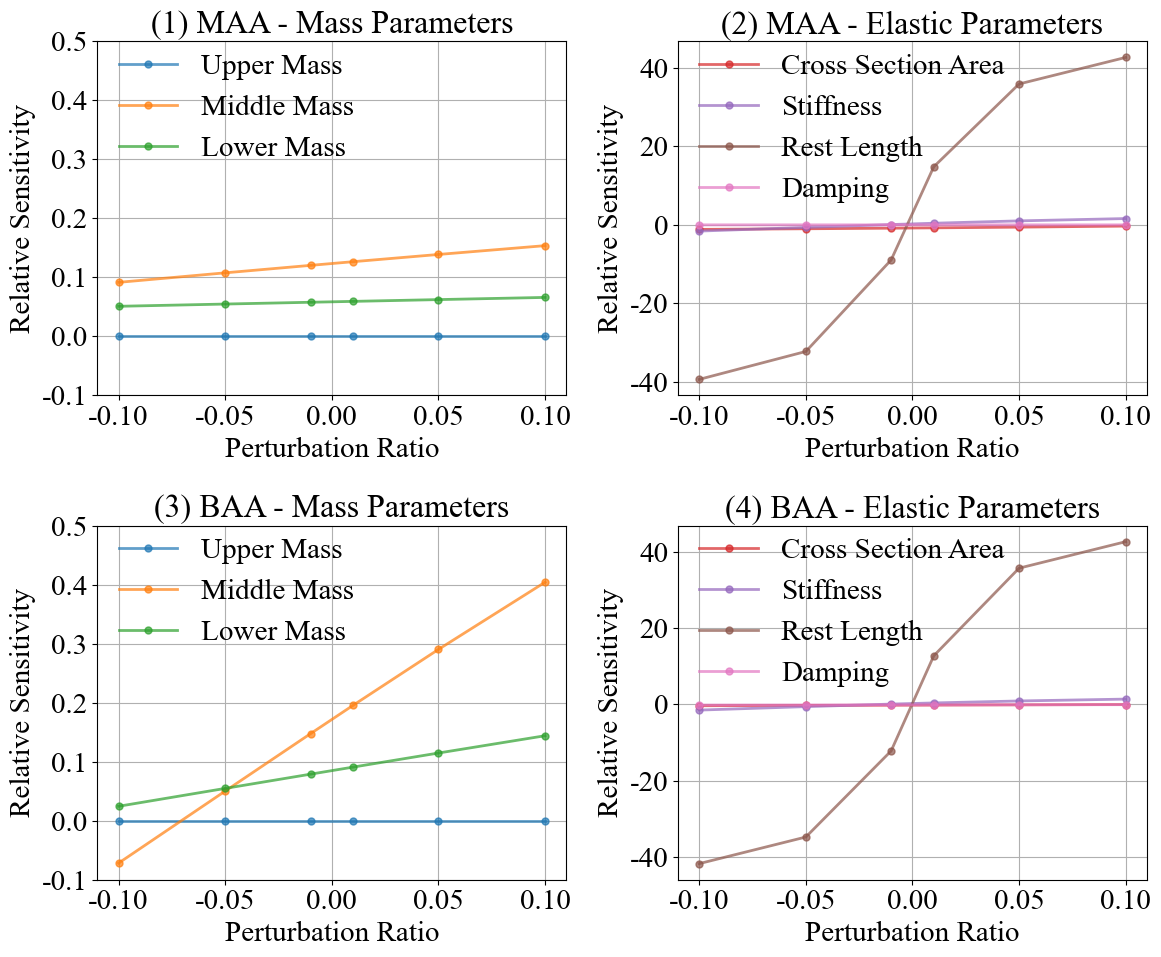

In [206]:
# analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import rcParams

config = {
    "font.family":'Times New Roman',  # 设置字体类型
    "axes.unicode_minus": False, #解决负号无法显示的问题
    "font.size": 21,  # 设置字体大小
}
rcParams.update(config)

df = result_log_df

# 重命名，rename/alias
alias_map = {
    'RB_MAA_uGeom': 'MAA Upper Mass',
    'RB_MAA_mGeom': 'MAA Middle Mass',
    'RB_MAA_lGeom': 'MAA Lower Mass',
    's1': 'MAA Cross Section Area',
    'stiffness_MAA': 'MAA Stiffness',
    'l10': 'MAA Rest Length',
    'damping_MAA': 'MAA Damping',

    'RB_BAA_uGeom': 'BAA Upper Mass',
    'RB_BAA_mGeom': 'BAA Middle Mass',
    'RB_BAA_lGeom': 'BAA Lower Mass',
    's2': 'BAA Cross Section Area',
    'stiffness_BAA': 'BAA Stiffness',
    'l20': 'BAA Rest Length',
    'damping_BAA': 'BAA Damping',
}

# 1. 保证顺序：用 alias_map 的顺序作为参数顺序
ordered_params = list(alias_map.keys())

# 设置颜色映射：每个参数一个颜色
params = df["parameter"].unique()
print(len(params)//2)
palette = sns.color_palette("tab10", len(params)//2)
color_map = {param: palette[i%len(palette)] for i, param in enumerate(ordered_params)}

# 创建 2x2 子图
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

plot_group = {
    0: ['RB_MAA_uGeom', 'RB_MAA_mGeom', 'RB_MAA_lGeom'],
    1: ['s1', 'stiffness_MAA', 'l10', 'damping_MAA'],
    2: ['RB_BAA_uGeom', 'RB_BAA_mGeom', 'RB_BAA_lGeom'], 
    3: ['s2', 'stiffness_BAA', 'l20', 'damping_BAA']
}

for i, ax in enumerate(axes):
    for param in plot_group[i]:
    
        label = alias_map[param][4:]

        # 绘制正扰动线（实线 + o）
        ax.plot(df[df['parameter'] == param]['delta_ratio'], 
                df[df['parameter'] == param]['relative_sensitivity_plus'], 
                marker='o', linestyle='-', color=color_map[param], label=label, alpha=0.7, linewidth=2, markersize=5)

    ax.set_xlabel('Perturbation Ratio')
    ax.set_ylabel('Relative Sensitivity')
    if i%2==0:
        ax.set_ylim(-0.1, 0.5)
    name = {
        1: 'MAA - Mass Parameters',
        2: 'MAA - Elastic Parameters',
        3: 'BAA - Mass Parameters',
        4: 'BAA - Elastic Parameters'
    }
    ax.set_title(f"({i+1}) {name[i+1]}", fontsize=23)

    # 去重图例，只显示一次每个参数
    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys(), loc="upper left", bbox_to_anchor=(-0.01, 1.04), fontsize=21, frameon=False)

    ax.grid(True)

# plt.suptitle('Sensitivity Analysis of Parameters', fontsize=26)
plt.tight_layout()
# save
plt.savefig('./figure/sensitivity_analysis.png', dpi=300)
plt.show()


['RB_MAA_uGeom',
 'RB_MAA_mGeom',
 'RB_MAA_lGeom',
 'stiffness_MAA',
 'l10',
 'damping_MAA',
 's1',
 'RB_BAA_uGeom',
 'RB_BAA_mGeom',
 'RB_BAA_lGeom',
 'stiffness_BAA',
 'l20',
 'damping_BAA',
 's2']

In [162]:
color_map

{'RB_MAA_uGeom': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 'RB_MAA_mGeom': (1.0, 0.4980392156862745, 0.054901960784313725),
 'RB_MAA_lGeom': (0.17254901960784313,
  0.6274509803921569,
  0.17254901960784313),
 'stiffness_MAA': (0.12156862745098039,
  0.4666666666666667,
  0.7058823529411765),
 'l10': (1.0, 0.4980392156862745, 0.054901960784313725),
 'damping_MAA': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 's1': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 'RB_BAA_uGeom': (1.0, 0.4980392156862745, 0.054901960784313725),
 'RB_BAA_mGeom': (0.17254901960784313,
  0.6274509803921569,
  0.17254901960784313),
 'RB_BAA_lGeom': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 'stiffness_BAA': (1.0, 0.4980392156862745, 0.054901960784313725),
 'l20': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 'damping_BAA': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 's2': (1.0, 0.4980392156862

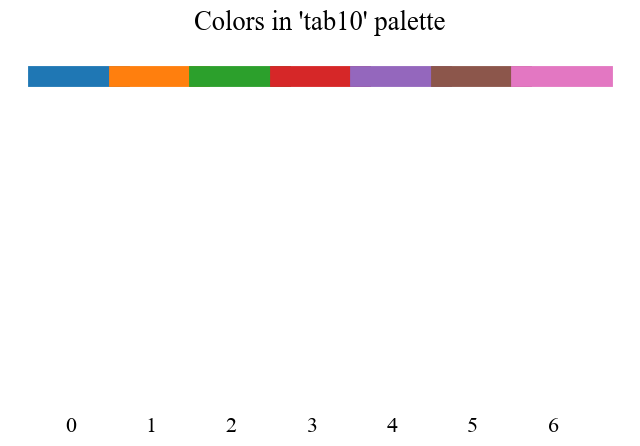

In [152]:

import seaborn as sns
import matplotlib.pyplot as plt

# 获取调色板
palette = sns.color_palette("tab10", 7)  # "tab10" 通常最多支持10种颜色

# 绘图显示颜色
plt.figure(figsize=(8, 1))
for i, color in enumerate(palette):
    plt.plot([i, i+1], [1, 1], lw=15, color=color)
    plt.text(i + 0.4, 0.5, f'{i}', ha='center', va='center')
plt.axis('off')
plt.title("Colors in 'tab10' palette")
plt.show()

In [147]:
color_map

{'RB_MAA_uGeom': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 'RB_MAA_mGeom': (0.6823529411764706, 0.7803921568627451, 0.9098039215686274),
 'RB_MAA_lGeom': (1.0, 0.4980392156862745, 0.054901960784313725),
 'RB_BAA_uGeom': (1.0, 0.7333333333333333, 0.47058823529411764),
 'RB_BAA_mGeom': (0.17254901960784313,
  0.6274509803921569,
  0.17254901960784313),
 'RB_BAA_lGeom': (0.596078431372549, 0.8745098039215686, 0.5411764705882353),
 'stiffness_MAA': (0.8392156862745098,
  0.15294117647058825,
  0.1568627450980392),
 'stiffness_BAA': (1.0, 0.596078431372549, 0.5882352941176471),
 'l10': (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 'l20': (0.7725490196078432, 0.6901960784313725, 0.8352941176470589),
 'damping_MAA': (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 'damping_BAA': (0.7686274509803922, 0.611764705882353, 0.5803921568627451),
 's1': (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 's2': (0.9686274509803922, 0.713

In [209]:
# baseline 分析！

def baseline_analysis(base_para, config_num=1/6, delta_ratio=0.05):
    # config_num: 用于控制质量扰动的幅度

    base_error = error(base_para)
    results = []

    MAA_mass = base_para['RB_MAA_uGeom'] + base_para['RB_MAA_mGeom'] + base_para['RB_MAA_lGeom']
    BAA_mass = base_para['RB_BAA_uGeom'] + base_para['RB_BAA_mGeom'] + base_para['RB_BAA_lGeom']

    new_para = base_para.copy()
    if config_num < 0:
        mini_mass = 1e-6
        new_para['RB_MAA_uGeom'] = MAA_mass * mini_mass
        new_para['RB_MAA_mGeom'] = MAA_mass * mini_mass
        new_para['RB_MAA_lGeom'] = MAA_mass * mini_mass

        new_para['RB_BAA_uGeom'] = BAA_mass * mini_mass
        new_para['RB_BAA_mGeom'] = BAA_mass * mini_mass
        new_para['RB_BAA_lGeom'] = BAA_mass * mini_mass
    else:
        new_para['RB_MAA_uGeom'] = MAA_mass * config_num
        new_para['RB_MAA_mGeom'] = MAA_mass * (1-2*config_num)
        new_para['RB_MAA_lGeom'] = MAA_mass * config_num

        new_para['RB_BAA_uGeom'] = BAA_mass * config_num
        new_para['RB_BAA_mGeom'] = BAA_mass * (1-2*config_num)
        new_para['RB_BAA_lGeom'] = BAA_mass * config_num

    new_error, expdata_all = error(new_para, return_type="frames")

    results.append({
        'config_num': config_num,
        'base_error': base_error,
        'new_value': new_error,
    })

    return results, expdata_all

results, expdata_sim_all = baseline_analysis(para, 1/2)
print(results)

[{'config_num': 0.5, 'base_error': np.float64(1.8633574817809353), 'new_value': np.float64(1.8529555337175483)}]


In [210]:

config_nums = np.linspace(0, 0.5, 7)
config_nums = [-1] + list(config_nums)
result_log = []
for idx in tqdm(range(len(config_nums))):
    df = baseline_analysis(para, config_num=config_nums[idx])
    result_log += df
print(result_log)

 33%|███▎      | 1/3 [00:02<00:05,  2.99s/it]


TypeError: cannot unpack non-iterable NoneType object

In [73]:
result_log = pd.DataFrame(result_log)
result_log

,config_num,base_error,new_value
0,-1.000000,48.075682,949.935755
1,0.000000,48.075682,1096.364222
2,0.083333,48.075682,47.975795
3,0.166667,48.075682,48.075682
4,0.250000,48.075682,48.879918
5,0.333333,48.075682,52.659169
6,0.416667,48.075682,56.072088
7,0.500000,48.075682,57.019853


In [249]:

# get all sim trajectory data
def evaluate_baseline(para):
    round_name = ['EquiMus', 'PureMuJoCo']
    exp_log = []
    for i, name in enumerate(round_name):
        para_run = para.copy()
        expdata_sim_all = []
        MAA_mass = para['RB_MAA_uGeom'] + para['RB_MAA_mGeom'] + para['RB_MAA_lGeom']
        BAA_mass = para['RB_BAA_uGeom'] + para['RB_BAA_mGeom'] + para['RB_BAA_lGeom']
        for p1, p2 in zip(P1_array, P2_array):
            para_run['P1'] = p1
            para_run['P2'] = p2

            # TODO: Baseline
            config_num = 1/6
            MIN_MASS = 1e-6
            if name == 'EquiMus':
                para_run['RB_MAA_uGeom'] = MAA_mass * config_num
                para_run['RB_MAA_mGeom'] = MAA_mass * (1-2*config_num)
                para_run['RB_MAA_lGeom'] = MAA_mass * config_num

                para_run['RB_BAA_uGeom'] = BAA_mass * config_num
                para_run['RB_BAA_mGeom'] = BAA_mass * (1-2*config_num)
                para_run['RB_BAA_lGeom'] = BAA_mass * config_num
            else:
                para_run['RB_MAA_uGeom'] = MIN_MASS
                para_run['RB_MAA_mGeom'] = MIN_MASS
                para_run['RB_MAA_lGeom'] = MIN_MASS

                para_run['RB_BAA_uGeom'] = MIN_MASS
                para_run['RB_BAA_mGeom'] = MIN_MASS
                para_run['RB_BAA_lGeom'] = MIN_MASS

            time_sim, theta1_sim, theta2_sim, _frames = run_single_experiment(para, ifrender=False)
            t_bias = 10
            time_sim = time_sim - t_bias
            t_intervel = np.linspace(0, 4, 401)
            theta1_sim_intervel = np.interp(t_intervel, time_sim, theta1_sim)
            theta2_sim_intervel = np.interp(t_intervel, time_sim, theta2_sim)
            expdata_sim = np.stack((t_intervel, theta1_sim_intervel, theta2_sim_intervel), axis=0) 
            expdata_sim_all.append(expdata_sim)
        expdata_sim_all = np.array(expdata_sim_all)
        traj_error = error(para=para_run)
        exp_log.append({
            'name': name,
            # 'expdata_sim_all': expdata_sim_all,
            'error': traj_error*np.pi/180
        })
    return exp_log


# cal the error
# print("Error: ", error(para=para))
exp_log = evaluate_baseline(para=para)
exp_log = pd.DataFrame(exp_log)
# save
exp_log.to_csv("./log/baseline_analysis.csv", index=False)
print(exp_log)


         name     error
0     EquiMus  0.032522
1  PureMuJoCo  0.432144


In [242]:
error(para)

np.float64(1.8529555337175483)

In [232]:

# get all sim trajectory data
expdata_sim_all = []
for p1, p2 in zip(P1_array, P2_array):
    para['P1'] = p1
    para['P2'] = p2

    # TODO: Baseline
    config_num = 1/6
    mini_mass = 1e-6
    MAA_mass = para['RB_MAA_uGeom'] + para['RB_MAA_mGeom'] + para['RB_MAA_lGeom']
    BAA_mass = para['RB_BAA_uGeom'] + para['RB_BAA_mGeom'] + para['RB_BAA_lGeom']
    para['RB_MAA_uGeom'] = mini_mass
    para['RB_MAA_mGeom'] = mini_mass
    para['RB_MAA_lGeom'] = mini_mass

    para['RB_BAA_uGeom'] = mini_mass
    para['RB_BAA_mGeom'] = mini_mass
    para['RB_BAA_lGeom'] = mini_mass


    time_sim, theta1_sim, theta2_sim, _frames = run_single_experiment(para, ifrender=False)
    t_bias = 10
    time_sim = time_sim - t_bias
    t_intervel = np.linspace(0, 4, 401)
    theta1_sim_intervel = np.interp(t_intervel, time_sim, theta1_sim)
    theta2_sim_intervel = np.interp(t_intervel, time_sim, theta2_sim)
    expdata_sim = np.stack((t_intervel, theta1_sim_intervel, theta2_sim_intervel), axis=0) 
    expdata_sim_all.append(expdata_sim)
expdata_sim_all = np.array(expdata_sim_all)

# cal the error
print("Error: ", error(para=para))
print(np.sum(expdata_sim_all))



Error:  24.7600178879689
21484.779123377826


/var/folders/j1/jvx4zg8j2kd3f52pd5cjwjrw0000gn/T/ipykernel_19881/2081909797.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])  # 调整子图间距，留出空间给图例


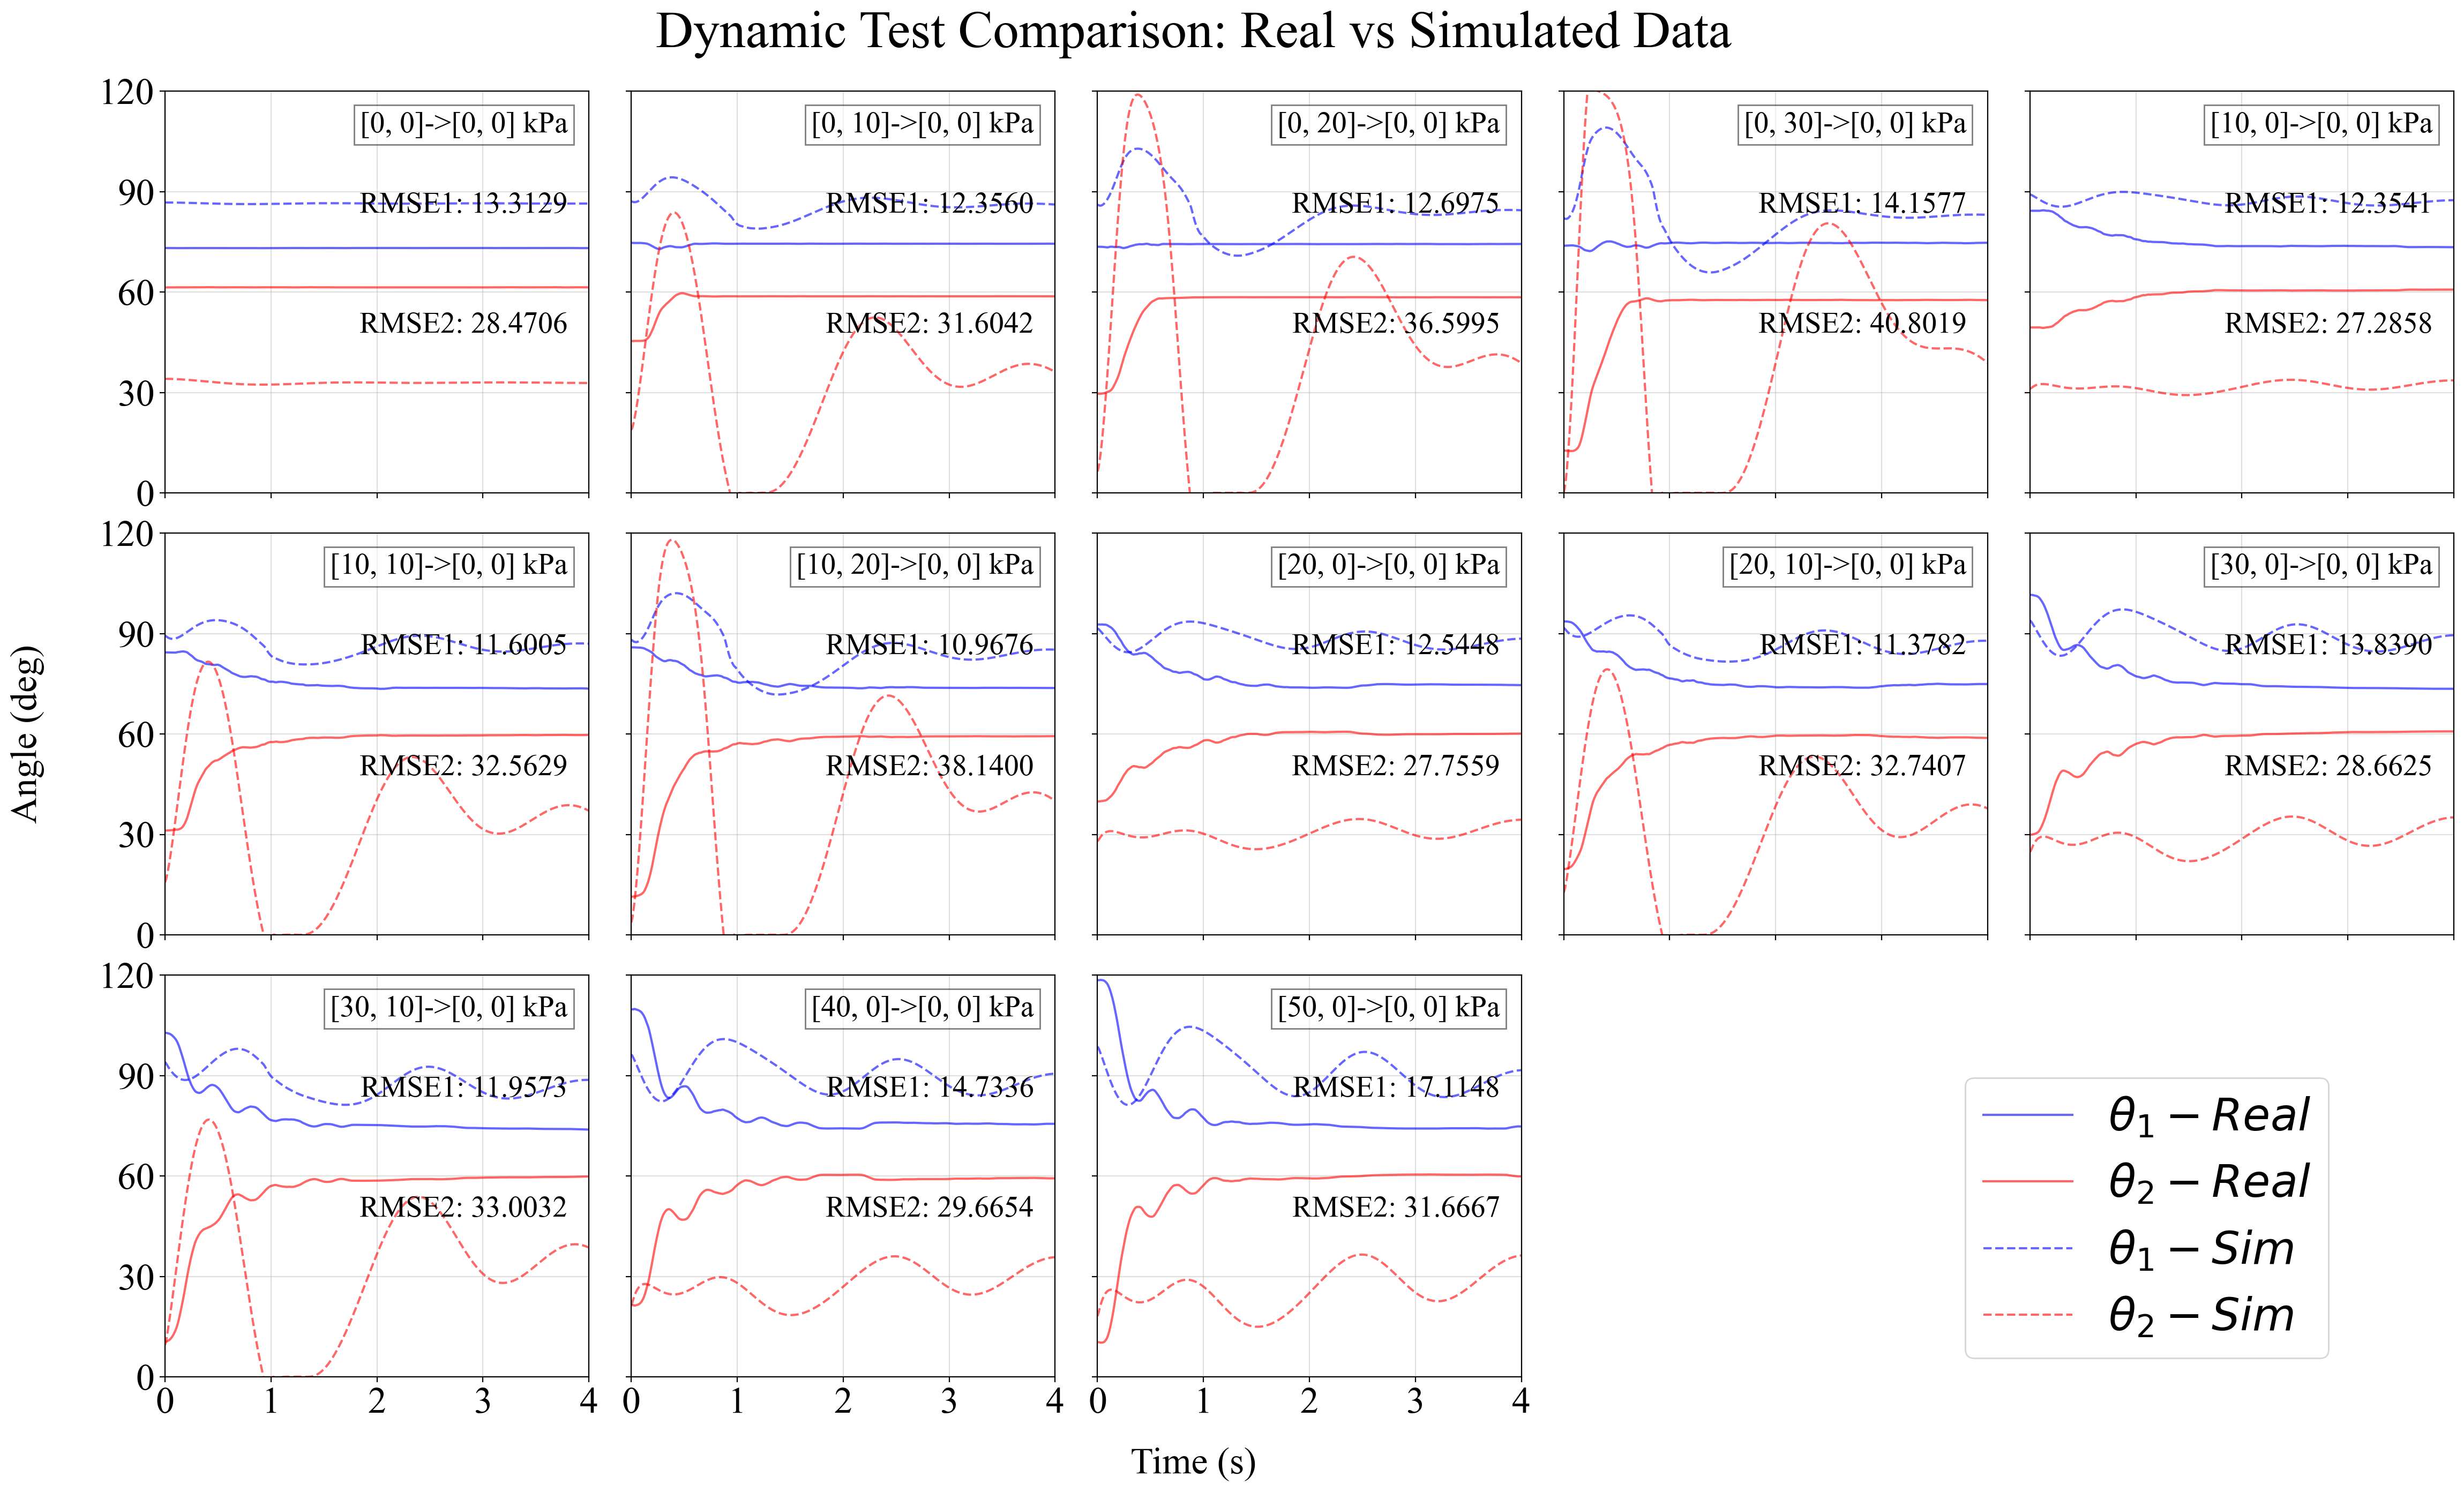

In [233]:

# draw the comparison
# 假设expdata_real_effective和expdata_sim_all是已经定义好的数据
num_experiments = len(expdata_real_lineInterp_effective_smooth)
ncols = 5  # 每行5张图
nrows = math.ceil(num_experiments / ncols)  # 根据实验数计算行数

from matplotlib import rcParams

config = {
    "font.family":'Times New Roman',  # 设置字体类型
    "axes.unicode_minus": False, #解决负号无法显示的问题
    "font.size": 16,  # 设置字体大小
}
rcParams.update(config)

legendSet = {
    # 'loc': 'upper right',
    'fontsize': 30,
}

axisSet = {
    'fontsize': 25,
}

textSet = {
    'fontsize': 20,
}

titleSet = {
    'fontsize': 35,
}

# 创建一个统一的网格布局
fig = plt.figure(figsize=(24, 15), dpi=200)  # 设置整个图形的大小
gs = gridspec.GridSpec(nrows, ncols, figure=fig, wspace=0.1, hspace=0.1, left=0.1, right=0.99, top=0.9, bottom=0.1)  # 设置子图间距

# 绘制每个实验的图形
for exp_id in range(num_experiments):
    ax = fig.add_subplot(gs[exp_id // ncols, exp_id % ncols])
    expdata_real, expdata_sim = expdata_real_lineInterp_effective_smooth[exp_id], expdata_sim_all[exp_id]
    if exp_id == 0:
        ax.plot(expdata_real[0], expdata_real[1], label=r"$\theta_1-Real$", color='blue', linestyle='-', alpha=0.6)
        ax.plot(expdata_real[0], expdata_real[2], label=r"$\theta_2-Real$", color='red', linestyle='-', alpha=0.6)
        ax.plot(expdata_sim[0], expdata_sim[1]*180/math.pi, label=r"$\theta_1-Sim$", color='blue', linestyle='--', alpha=0.6)
        ax.plot(expdata_sim[0], expdata_sim[2]*180/math.pi, label=r"$\theta_2-Sim$", color='red', linestyle='--', alpha=0.6)
    else:
        ax.plot(expdata_real[0], expdata_real[1], color='blue', linestyle='-', alpha=0.6)
        ax.plot(expdata_real[0], expdata_real[2], color='red', linestyle='-', alpha=0.6)
        ax.plot(expdata_sim[0], expdata_sim[1]*180/math.pi, color='blue', linestyle='--', alpha=0.6)
        ax.plot(expdata_sim[0], expdata_sim[2]*180/math.pi, color='red', linestyle='--', alpha=0.6)
    # ax.set_title(f"Experiment {exp_id + 1}")
    # 在右上角添加标注
    ax.text(0.95, 0.95, f'[{int(P1_array[exp_id]/1000):d}, {int(P2_array[exp_id]/1000):d}]->[0, 0] kPa', transform=ax.transAxes, 
            ha='right', va='top', fontsize=textSet['fontsize'], bbox=dict(facecolor='white', alpha=0.5))
    # text: RMSE
    RMSE_THETA1 = np.sqrt(np.mean((expdata_real[1]-expdata_sim[1]*180/math.pi)**2))
    RMSE_THETA2 = np.sqrt(np.mean((expdata_real[2]-expdata_sim[2]*180/math.pi)**2))
    ax.text(0.95, 0.75, f"RMSE1: {RMSE_THETA1:.4f}", transform=ax.transAxes, 
            ha='right', va='top', fontsize=textSet['fontsize'])
    ax.text(0.95, 0.45, f"RMSE2: {RMSE_THETA2:.4f}", transform=ax.transAxes,
            ha='right', va='top', fontsize=textSet['fontsize'])
    
    ax.grid(alpha=0.4)  # 添加网格线
    ax.set_xlim(0, 4)  # 设置x轴范围
    ax.set_ylim(0, 120)  # 设置y轴范围
    ax.set_xticks(np.arange(0, 4.1, 1))  # 设置x轴刻度
    ax.set_yticks(np.arange(0, 120.1, 30))  # 设置y轴刻度
    # 设置刻度字体大小
    ax.tick_params(axis='both', labelsize=axisSet['fontsize'])  # 12
    if exp_id%ncols != 0:   # 如果不在最左边
        ax.set_yticklabels([])  # 隐藏y轴刻度
    if exp_id//ncols != nrows-1:  # 如果不在最下面
        ax.set_xticklabels([])  # 隐藏x轴刻度


# 设置统一的x轴和y轴标签
fig.text(0.5, 0.04, 'Time (s)', ha='center', fontsize=axisSet['fontsize'])
fig.text(0.04, 0.5, 'Angle (deg)', va='center', rotation='vertical', fontsize=axisSet['fontsize'])

# 添加全图图名
fig.suptitle('Dynamic Test Comparison: Real vs Simulated Data', fontsize=titleSet['fontsize'], y=0.95)

# 添加统一的图例
handles, labels = [], []
for ax in fig.axes:
    for handle, label in zip(*ax.get_legend_handles_labels()):
        handles.append(handle)
        labels.append(label)
fig.legend(handles, labels, bbox_to_anchor=(0.95, 0.3), ncol=1, fontsize=legendSet['fontsize'])  # 添加图例

# 调整子图间距
plt.tight_layout(rect=[0, 0, 1, 0.95])  # 调整子图间距，留出空间给图例
plt.show()

